In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

with zipfile.ZipFile('archive.zip') as z:
    with z.open('songs_with_attributes_and_lyrics.csv') as f:
        df_buyuk = pd.read_csv(f, nrows=120000)

print(f'Yuklenen sarki: {len(df_buyuk):,}')

Yuklenen sarki: 120,000


In [2]:
spotify = pd.read_csv('spotify-tracks-dataset (1) (1).csv')

# Normalize et
df_buyuk['name_clean'] = df_buyuk['name'].str.lower().str.strip()
df_buyuk['artist_clean'] = df_buyuk['artists'].str.lower().str.strip()

spotify['name_clean'] = spotify['track_name'].str.lower().str.strip()
spotify['artist_clean'] = spotify['artists'].str.lower().str.split(';').str[0].str.strip()

# Birleştir
df_merged = pd.merge(
    df_buyuk,
    spotify[['name_clean', 'artist_clean', 'popularity', 'track_genre']],
    on=['name_clean', 'artist_clean'],
    how='inner'
).drop_duplicates(subset=['name_clean', 'artist_clean'])

print(f'Veri Seti 1: {len(df_buyuk):,} sarki')
print(f'Veri Seti 2: {len(spotify):,} sarki')
print(f'Eslesen sarki sayisi: {len(df_merged):,}')

Veri Seti 1: 120,000 sarki
Veri Seti 2: 114,000 sarki
Eslesen sarki sayisi: 5,237


In [4]:
# Değişken 1: Canlılık Endeksi
df_merged['canlilik_endeksi'] = df_merged['danceability'] * df_merged['energy']

# Değişken 2: Duygu Skoru
df_merged['duygu_skoru'] = df_merged['valence']
df_merged['duygu_etiketi'] = df_merged['duygu_skoru'].apply(
    lambda x: 'pozitif' if x > 0.6 else ('negatif' if x < 0.4 else 'notr')
)

# Değişken 3: Güvenilir Popülerlik Skoru
df_merged['guvenir_popularite'] = df_merged['popularity'] * np.log1p(df_merged['valence'])

# Değişken 4: Tahmini Dinlenme Süresi
df_merged['dinlenme_suresi_tahmini'] = (df_merged['duration_ms'] / 1000) * df_merged['canlilik_endeksi']

print('4 yeni degisken turetildi!')
print(f"canlilik_endeksi        → Ortalama: {df_merged['canlilik_endeksi'].mean():.3f}")
print(f"duygu_skoru             → Ortalama: {df_merged['duygu_skoru'].mean():.3f}")
print(f"guvenir_popularite      → Ortalama: {df_merged['guvenir_popularite'].mean():.2f}")
print(f"dinlenme_suresi_tahmini → Ortalama: {df_merged['dinlenme_suresi_tahmini'].mean():.2f}")
print(f"\nDuygu dagilimi:\n{df_merged['duygu_etiketi'].value_counts()}")

4 yeni degisken turetildi!
canlilik_endeksi        → Ortalama: 0.379
duygu_skoru             → Ortalama: 0.506
guvenir_popularite      → Ortalama: 15.31
dinlenme_suresi_tahmini → Ortalama: 84.09

Duygu dagilimi:
duygu_etiketi
negatif    1977
pozitif    1952
notr       1308
Name: count, dtype: int64


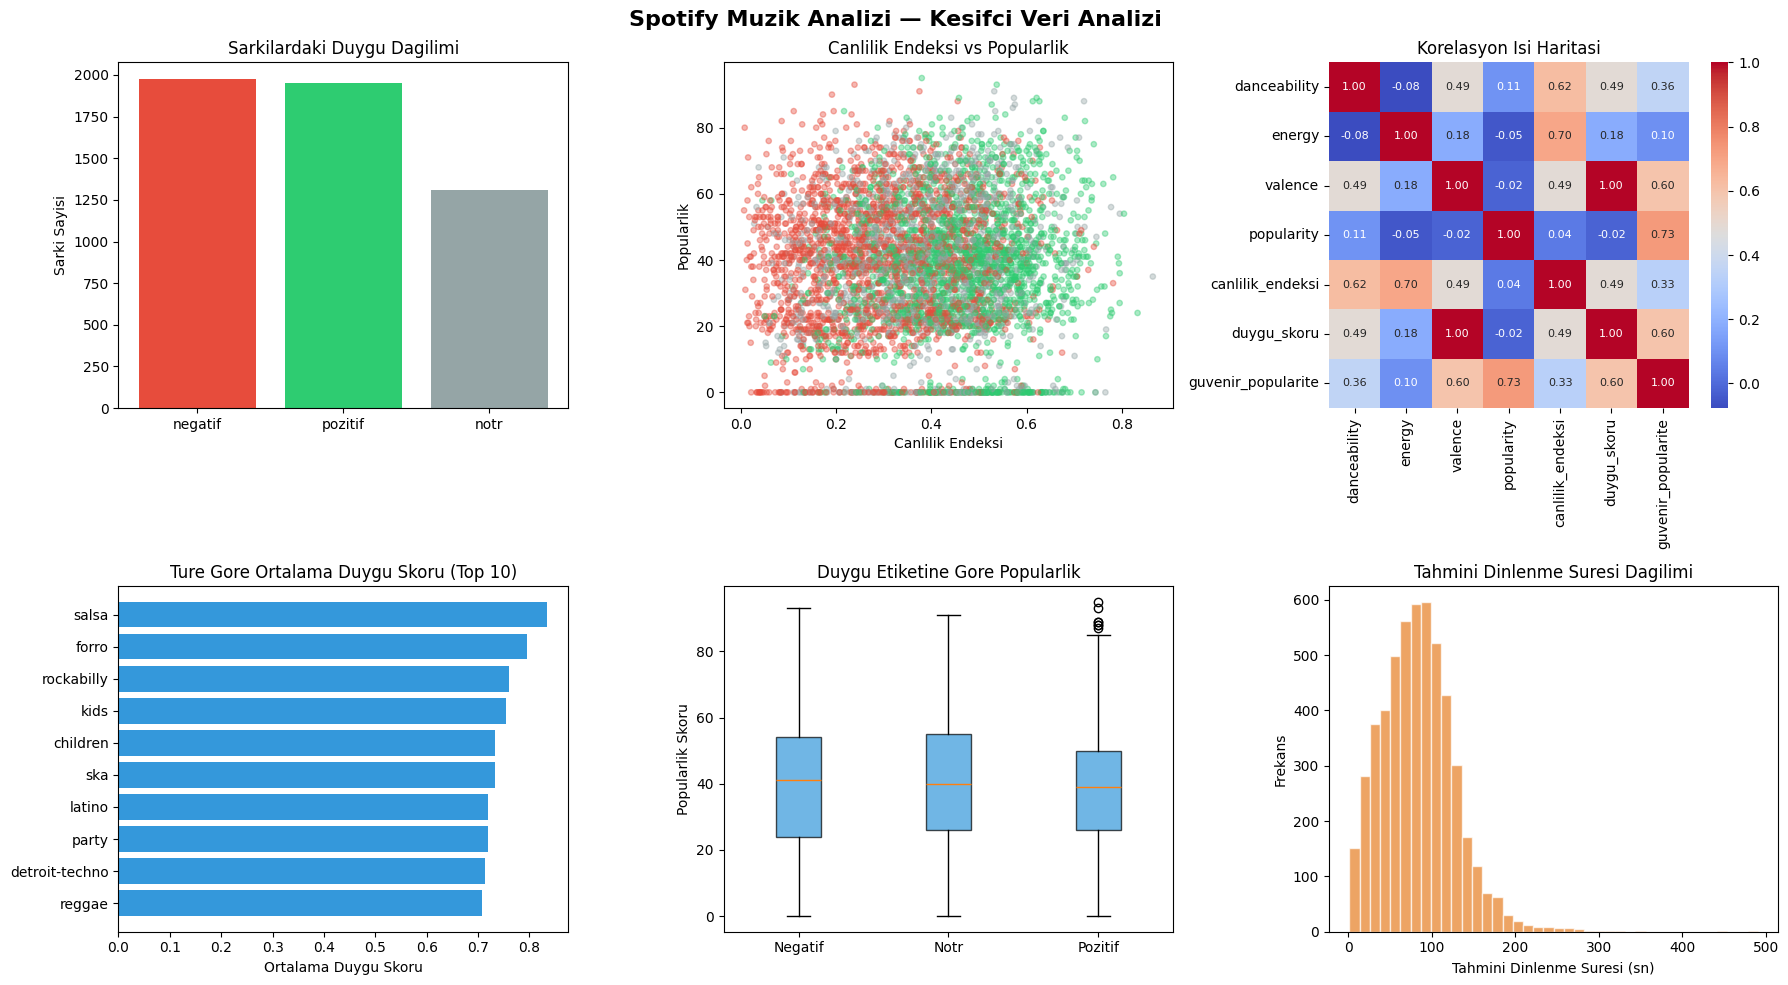

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Spotify Muzik Analizi — Kesifci Veri Analizi', fontsize=16, fontweight='bold')

colors = {'pozitif': '#2ecc71', 'notr': '#95a5a6', 'negatif': '#e74c3c'}

# 1. Duygu dağılımı
duygu_counts = df_merged['duygu_etiketi'].value_counts()
axes[0,0].bar(duygu_counts.index, duygu_counts.values,
               color=[colors[x] for x in duygu_counts.index])
axes[0,0].set_title('Sarkilardaki Duygu Dagilimi')
axes[0,0].set_ylabel('Sarki Sayisi')

# 2. Canlılık vs Popularity
scatter_colors = [colors[x] for x in df_merged['duygu_etiketi']]
axes[0,1].scatter(df_merged['canlilik_endeksi'], df_merged['popularity'],
                   c=scatter_colors, alpha=0.4, s=15)
axes[0,1].set_title('Canlilik Endeksi vs Popularlik')
axes[0,1].set_xlabel('Canlilik Endeksi')
axes[0,1].set_ylabel('Popularlik')

# 3. Korelasyon ısı haritası
corr_cols = ['danceability','energy','valence','popularity',
             'canlilik_endeksi','duygu_skoru','guvenir_popularite']
sns.heatmap(df_merged[corr_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', ax=axes[0,2], annot_kws={'size': 8})
axes[0,2].set_title('Korelasyon Isi Haritasi')

# 4. Türe göre duygu skoru
genre_duygu = df_merged.groupby('track_genre')['duygu_skoru'].mean().sort_values().tail(10)
axes[1,0].barh(genre_duygu.index, genre_duygu.values, color='#3498db')
axes[1,0].set_title('Ture Gore Ortalama Duygu Skoru (Top 10)')
axes[1,0].set_xlabel('Ortalama Duygu Skoru')

# 5. Duygu etiketine göre popularity box plot
box_data = [df_merged[df_merged['duygu_etiketi']==e]['popularity'].values
            for e in ['negatif', 'notr', 'pozitif']]
axes[1,1].boxplot(box_data, labels=['Negatif','Notr','Pozitif'],
                   patch_artist=True,
                   boxprops=dict(facecolor='#3498db', alpha=0.7))
axes[1,1].set_title('Duygu Etiketine Gore Popularlik')
axes[1,1].set_ylabel('Popularlik Skoru')

# 6. Dinlenme süresi dağılımı
axes[1,2].hist(df_merged['dinlenme_suresi_tahmini'], bins=40,
               color='#e67e22', alpha=0.7, edgecolor='white')
axes[1,2].set_title('Tahmini Dinlenme Suresi Dagilimi')
axes[1,2].set_xlabel('Tahmini Dinlenme Suresi (sn)')
axes[1,2].set_ylabel('Frekans')

plt.tight_layout()
plt.show()

Populer: 794 | Degil: 4443

=== MODEL PERFORMANSI ===
               precision    recall  f1-score   support

Populer Degil       0.94      1.00      0.97       885
      Populer       0.99      0.66      0.79       163

     accuracy                           0.95      1048
    macro avg       0.97      0.83      0.88      1048
 weighted avg       0.95      0.95      0.94      1048



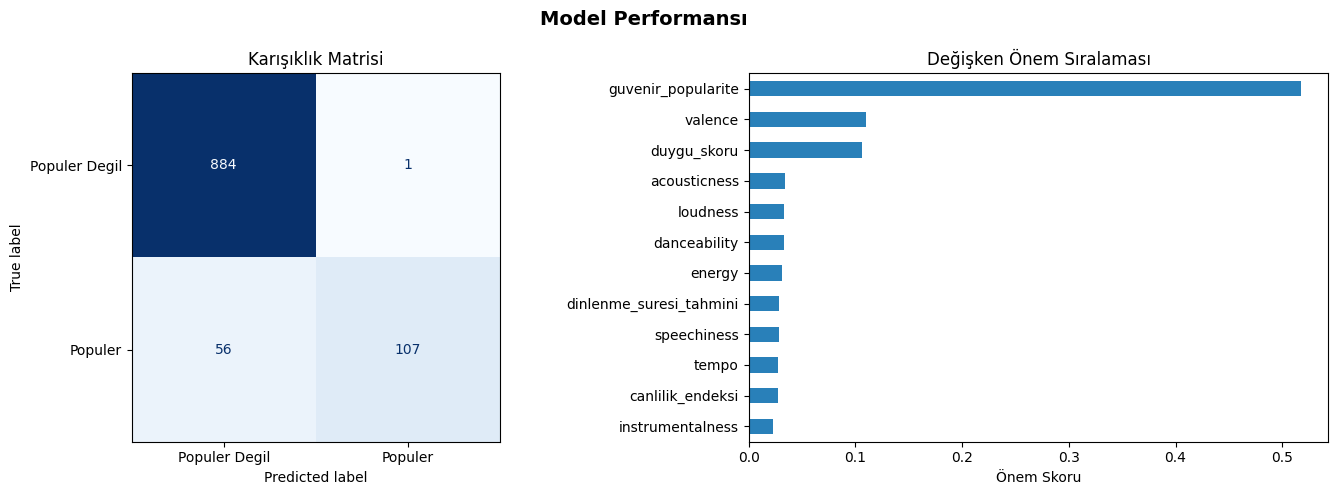

In [6]:
# Hedef değişken
df_merged['populer'] = (df_merged['popularity'] >= 60).astype(int)
print(f"Populer: {df_merged['populer'].sum()} | Degil: {(df_merged['populer']==0).sum()}")

features = ['danceability', 'energy', 'valence', 'tempo', 'loudness',
            'acousticness', 'speechiness', 'instrumentalness',
            'canlilik_endeksi', 'duygu_skoru', 'guvenir_popularite',
            'dinlenme_suresi_tahmini']

X = df_merged[features].fillna(0)
y = df_merged['populer']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=10)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print('\n=== MODEL PERFORMANSI ===')
print(classification_report(y_test, y_pred, target_names=['Populer Degil', 'Populer']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Performansı', fontsize=14, fontweight='bold')

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Populer Degil','Populer']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Karışıklık Matrisi')

imp = pd.Series(model.feature_importances_, index=features).sort_values()
imp.plot(kind='barh', ax=axes[1], color='#2980b9')
axes[1].set_title('Değişken Önem Sıralaması')
axes[1].set_xlabel('Önem Skoru')
plt.tight_layout()
plt.show()

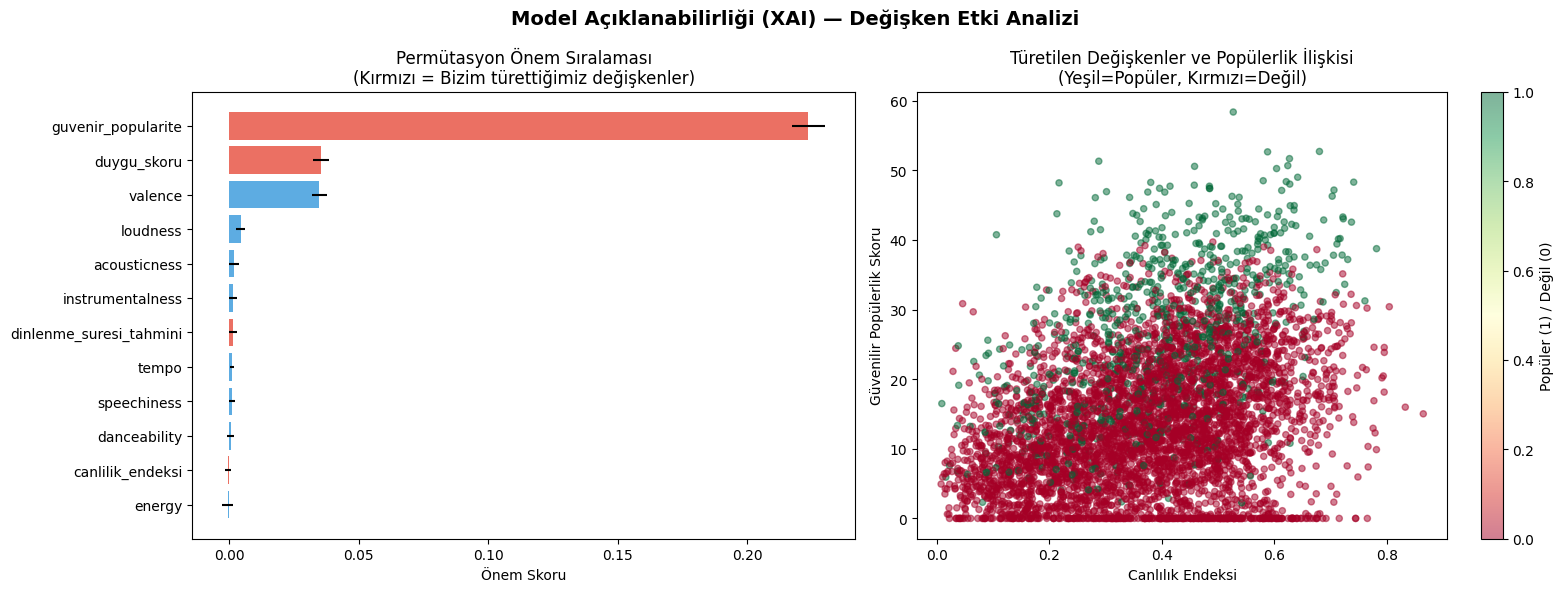


En etkili 3 değişken:
           feature  importance_mean
           valence         0.034828
       duygu_skoru         0.035401
guvenir_popularite         0.223664


In [7]:
perm = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
perm_df = pd.DataFrame({
    'feature': features,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Açıklanabilirliği (XAI) — Değişken Etki Analizi',
             fontsize=14, fontweight='bold')

renkler = ['#e74c3c' if f in ['canlilik_endeksi', 'duygu_skoru',
           'guvenir_popularite', 'dinlenme_suresi_tahmini']
           else '#3498db' for f in perm_df['feature']]

axes[0].barh(perm_df['feature'], perm_df['importance_mean'],
              xerr=perm_df['importance_std'], color=renkler, alpha=0.8)
axes[0].set_title('Permütasyon Önem Sıralaması\n(Kırmızı = Bizim türettiğimiz değişkenler)')
axes[0].set_xlabel('Önem Skoru')

sc = axes[1].scatter(df_merged['canlilik_endeksi'], df_merged['guvenir_popularite'],
               c=df_merged['populer'], cmap='RdYlGn', alpha=0.5, s=20)
axes[1].set_xlabel('Canlılık Endeksi')
axes[1].set_ylabel('Güvenilir Popülerlik Skoru')
axes[1].set_title('Türetilen Değişkenler ve Popülerlik İlişkisi\n(Yeşil=Popüler, Kırmızı=Değil)')
plt.colorbar(sc, ax=axes[1], label='Popüler (1) / Değil (0)')

plt.tight_layout()
plt.show()

print('\nEn etkili 3 değişken:')
print(perm_df.tail(3)[['feature', 'importance_mean']].to_string(index=False))

      FİNANSAL SİMÜLASYON SONUÇLARI
Ücretsiz kullanıcı sayısı  :     300,000,000
Mevcut geçiş oranı         : %2.0
Model ile geçiş oranı      : %3.5
Ekstra premium kullanıcı   :       4,500,000
Aylık ekstra gelir         : $    44,955,000
Yıllık ekstra gelir        : $   539,460,000


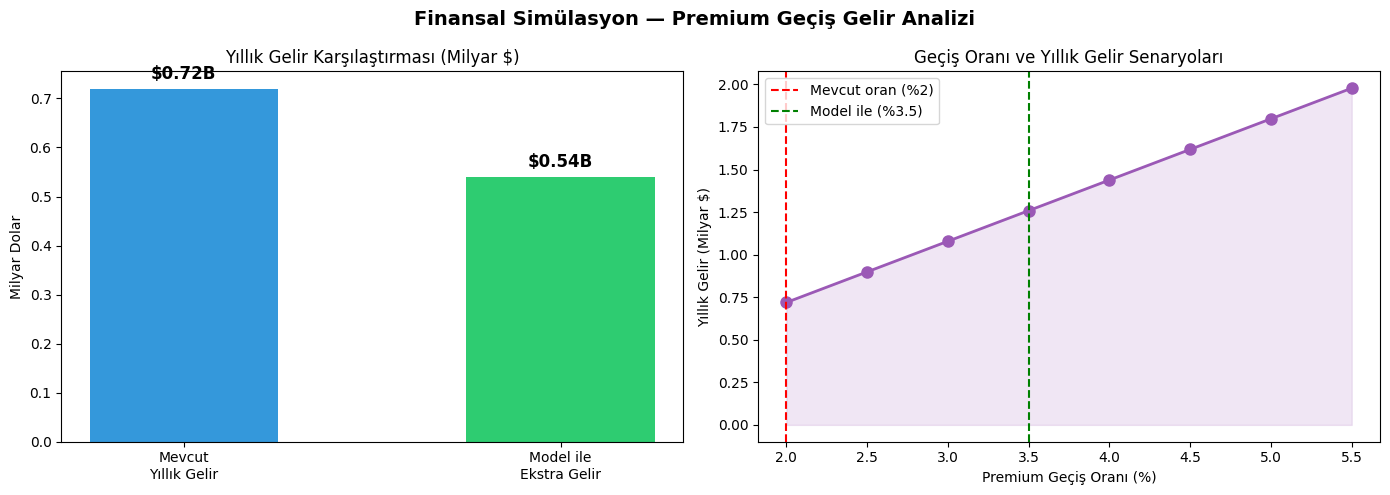

In [8]:
# Varsayımlar
toplam_kullanici    = 500_000_000
ucretsiz_oran       = 0.60
premium_aylik       = 9.99

ucretsiz_kullanici  = toplam_kullanici * ucretsiz_oran
baseline_gecis      = 0.020
model_gecis         = 0.035

ekstra_kullanici    = ucretsiz_kullanici * (model_gecis - baseline_gecis)
aylik_ekstra_gelir  = ekstra_kullanici * premium_aylik
yillik_ekstra_gelir = aylik_ekstra_gelir * 12

print('=' * 50)
print('      FİNANSAL SİMÜLASYON SONUÇLARI')
print('=' * 50)
print(f'Ücretsiz kullanıcı sayısı  : {ucretsiz_kullanici:>15,.0f}')
print(f'Mevcut geçiş oranı         : %{baseline_gecis*100:.1f}')
print(f'Model ile geçiş oranı      : %{model_gecis*100:.1f}')
print(f'Ekstra premium kullanıcı   : {ekstra_kullanici:>15,.0f}')
print(f'Aylık ekstra gelir         : ${aylik_ekstra_gelir:>14,.0f}')
print(f'Yıllık ekstra gelir        : ${yillik_ekstra_gelir:>14,.0f}')
print('=' * 50)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Finansal Simülasyon — Premium Geçiş Gelir Analizi',
             fontsize=14, fontweight='bold')

labels = ['Mevcut\nYıllık Gelir', 'Model ile\nEkstra Gelir']
values = [ucretsiz_kullanici * baseline_gecis * premium_aylik * 12 / 1e9,
          yillik_ekstra_gelir / 1e9]
bars = axes[0].bar(labels, values, color=['#3498db', '#2ecc71'], width=0.5)
axes[0].set_title('Yıllık Gelir Karşılaştırması (Milyar $)')
axes[0].set_ylabel('Milyar Dolar')
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                  f'${val:.2f}B', ha='center', fontweight='bold', fontsize=12)

oranlar = np.arange(0.02, 0.06, 0.005)
gelirler = [ucretsiz_kullanici * o * premium_aylik * 12 / 1e9 for o in oranlar]
axes[1].plot(oranlar*100, gelirler, 'o-', color='#9b59b6', linewidth=2, markersize=8)
axes[1].axvline(x=baseline_gecis*100, color='red', linestyle='--', label='Mevcut oran (%2)')
axes[1].axvline(x=model_gecis*100, color='green', linestyle='--', label='Model ile (%3.5)')
axes[1].fill_between(oranlar*100, gelirler, alpha=0.15, color='#9b59b6')
axes[1].set_title('Geçiş Oranı ve Yıllık Gelir Senaryoları')
axes[1].set_xlabel('Premium Geçiş Oranı (%)')
axes[1].set_ylabel('Yıllık Gelir (Milyar $)')
axes[1].legend()

plt.tight_layout()
plt.show()